In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from tensorflow.keras.applications.densenet import preprocess_input,DenseNet121
import tensorflow.keras.layers as tfl

In [2]:
TRAIN_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/train/'
VAL_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/val/'
TEST_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/'

In [3]:
classes=os.listdir(TRAIN_PATH)[1:]

for class_ in classes:
    print(f"{class_ } : {len(os.listdir(TRAIN_PATH+class_))}")

COVID : 1000
Normal : 1000
Viral Pneumonia : 1000


In [4]:
train_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)
val_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input
)
test_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
IMG_SIZE=(224,224)
BATCH_SIZE=32

train_generator=train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
val_generator=val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Found 435 images belonging to 3 classes.


In [6]:
print(train_generator.class_indices)

{'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [7]:
base_model=DenseNet121(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False

In [8]:
x=base_model.output
x=tfl.GlobalAveragePooling2D()(x)
x=tfl.Dropout(0.3)(x)
outputs=tfl.Dense(len(classes),activation='softmax')(x)

model=tf.keras.Model(inputs=base_model.input,outputs=outputs)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

callbacks=[
    EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),
    ModelCheckpoint('models/best_model.keras',save_best_only=True)
]

In [11]:
history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
94/94 [==============================] - 46s 369ms/step - loss: 0.7728 - accuracy: 0.6677 - val_loss: 0.4027 - val_accuracy: 0.8467
Epoch 2/15
94/94 [==============================] - 30s 323ms/step - loss: 0.5071 - accuracy: 0.7743 - val_loss: 0.3509 - val_accuracy: 0.8517
Epoch 3/15
94/94 [==============================] - 30s 316ms/step - loss: 0.4299 - accuracy: 0.8107 - val_loss: 0.3095 - val_accuracy: 0.8833
Epoch 4/15
94/94 [==============================] - 30s 318ms/step - loss: 0.3953 - accuracy: 0.8347 - val_loss: 0.2898 - val_accuracy: 0.8867
Epoch 5/15
94/94 [==============================] - 30s 318ms/step - loss: 0.3607 - accuracy: 0.8467 - val_loss: 0.2745 - val_accuracy: 0.8833
Epoch 6/15
94/94 [==============================] - 31s 325ms/step - loss: 0.3562 - accuracy: 0.8523 - val_loss: 0.2625 - val_accuracy: 0.9033
Epoch 7/15
94/94 [==============================] - 29s 312ms/step - loss: 0.3383 - accuracy: 0.8530 - val_loss: 0.2599 - val_accuracy: 0.8950

In [12]:
base_model.trainable=True

for layer in base_model.layers[:-20]:
    layer.trainable=False
    
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
94/94 [==============================] - 40s 345ms/step - loss: 0.4424 - accuracy: 0.8293 - val_loss: 0.3217 - val_accuracy: 0.8583
Epoch 2/15
94/94 [==============================] - 32s 344ms/step - loss: 0.3031 - accuracy: 0.8807 - val_loss: 0.2064 - val_accuracy: 0.9167
Epoch 3/15
94/94 [==============================] - 32s 337ms/step - loss: 0.2767 - accuracy: 0.8923 - val_loss: 0.1856 - val_accuracy: 0.9267
Epoch 4/15
94/94 [==============================] - 31s 334ms/step - loss: 0.2684 - accuracy: 0.8937 - val_loss: 0.1747 - val_accuracy: 0.9400
Epoch 5/15
94/94 [==============================] - 31s 327ms/step - loss: 0.2589 - accuracy: 0.8983 - val_loss: 0.1563 - val_accuracy: 0.9417
Epoch 6/15
94/94 [==============================] - 31s 327ms/step - loss: 0.2162 - accuracy: 0.9113 - val_loss: 0.1478 - val_accuracy: 0.9467
Epoch 7/15
94/94 [==============================] - 31s 326ms/step - loss: 0.2116 - accuracy: 0.9160 - val_loss: 0.1467 - val_accuracy: 0.9433

In [13]:
model.evaluate(train_generator)

94/94 [==============================] - 27s 291ms/step - loss: 0.0497 - accuracy: 0.9833


[0.049704186618328094, 0.9833333492279053]

In [14]:
model.evaluate(val_generator)

19/19 [==============================] - 2s 97ms/step - loss: 0.1055 - accuracy: 0.9633


[0.10551509261131287, 0.9633333086967468]

In [15]:
from tensorflow.keras.models import load_model

model=load_model('models/best_model.keras')
model.evaluate(test_generator)

14/14 [==============================] - 5s 229ms/step - loss: 0.0807 - accuracy: 0.9747


[0.08074163645505905, 0.9747126698493958]

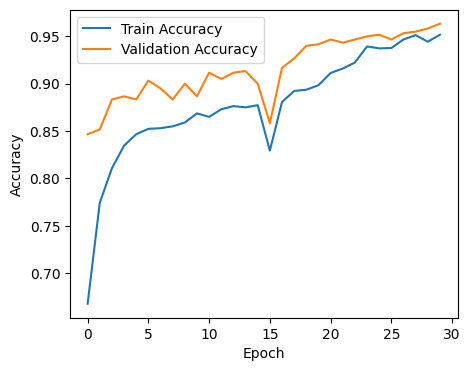

In [23]:
plt.figure(figsize=(5,4))
plt.plot(history.history['accuracy']+history_fine.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy']+history_fine.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
history.history['']

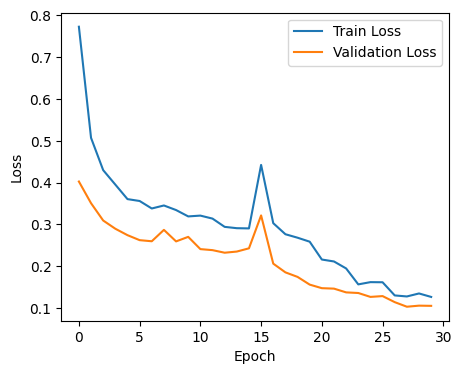

In [24]:
plt.figure(figsize=(5,4))
plt.plot(history.history['loss']+history_fine.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss']+history_fine.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import classification_report,confusion_matrix

y_true=test_generator.classes
y_pred=model.predict(test_generator,verbose=0)
y_pred_classes=tf.argmax(y_pred,axis=1)
print(classification_report(y_true,y_pred_classes,target_names=classes))

                 precision    recall  f1-score   support

          COVID       0.98      0.95      0.97       145
         Normal       0.95      0.97      0.96       145
Viral Pneumonia       0.99      1.00      1.00       145

       accuracy                           0.97       435
      macro avg       0.97      0.97      0.97       435
   weighted avg       0.97      0.97      0.97       435



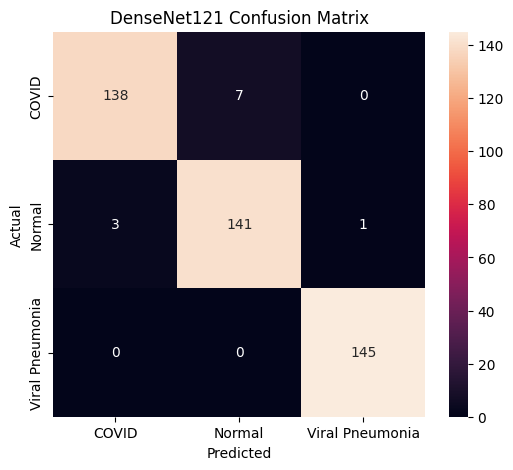

In [26]:
cm=confusion_matrix(y_true,y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 Confusion Matrix")
plt.show()